# Patient transfer adaptation through a crisis: The dynamics of a Hospitals Network during the COVID-19 pandemic.

**Autores:** Cicchini Tomás, Salgado Ariel, Otero Lisandro, Goldman Mariano, Yacobitti Alejandro, Doldan Victoria, Kochen Silvia, Boechi Leonardo, Caridi Inés.

_Instituto del Cálculo (UBA-CONICET), Hospital de Alta Complejidad en Red Nestor Carlos Kirchner, ENYS (CONICET-HEC-UNAJ), y desarrollador free-lance._


In [ ]:
import sys
sys.path.append("..")  # agrega raiz del proyecto al path

from scripts import bases, init_notebook as init


In [ ]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init.init_notebook(data_path="../data")

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


In [ ]:
# Carga todos los datos del proyecto de una vez
ctx_datos = init.init_notebook(data_path="../data")

df_pacientes    = ctx_datos["df_pacientes"]
traslados       = ctx_datos["traslados"]
hosp_coords     = ctx_datos["hosp_coords"]
municipios      = ctx_datos["municipios"]
municipios_amba = ctx_datos["municipios_amba"]


## The hospital network and the data.

**Contexto:** El trabajo en red permite optimizar recursos en momentos críticos.  
**Impacto COVID-19:** La pandemia puso en crisis a los sistemas de salud y obligó a adaptar infraestructuras.  
**Red Sudeste:** El sistema informático recolectó datos de camas y traslados de 14 hospitales de la Red Sudeste. Abarca cuatro municipios: Quilmes (QU), Almirante Brown (AB), Florencio Varela (FV) y Berazategui (BE), cubriendo 661 km² y casi 2 millones de habitantes.


In [81]:
# Mapas (Paneles A, B y C)
# A. Aquí se visualiza la Provincia de Buenos Aires (PBA)

# ----------------------------
# cargar datos
# ----------------------------

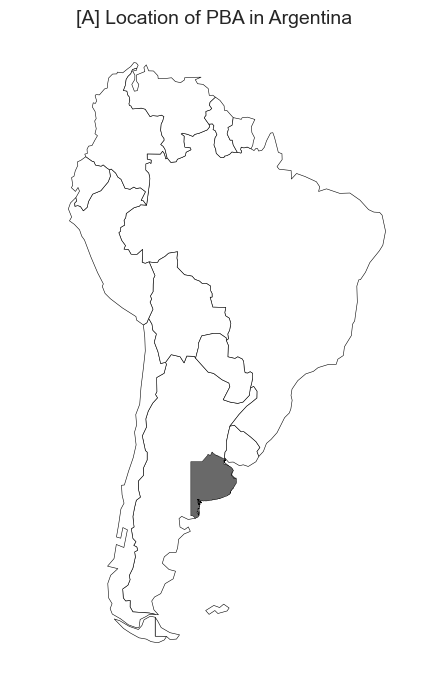

In [82]:
# -------------------------
# cargar Natural Earth países
# -------------------------
paises = gpd.read_file("../data/ne_countries/ne_110m_admin_0_countries.shp")

# solo Sudamérica
sudamerica = paises[paises["CONTINENT"] == "South America"]

# -------------------------
# cargar provincias argentinas
# -------------------------
provincias = gpd.read_file("../data/provincias_ign/provinciaPolygon.shp")

# Buenos Aires
pba = provincias[provincias["nam"] == "Buenos Aires"]

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(7,7))

# Sudamérica
sudamerica.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.4
)

# Buenos Aires resaltada
pba.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.3
)

# centrar el mapa
ax.set_xlim(-90, -30)
ax.set_ylim(-60, 15)

# título
ax.set_title(
    "[A] Location of PBA in Argentina",
    fontsize=14,
    pad=12
)

# quitar ejes
ax.axis("off")

plt.tight_layout()
plt.show()

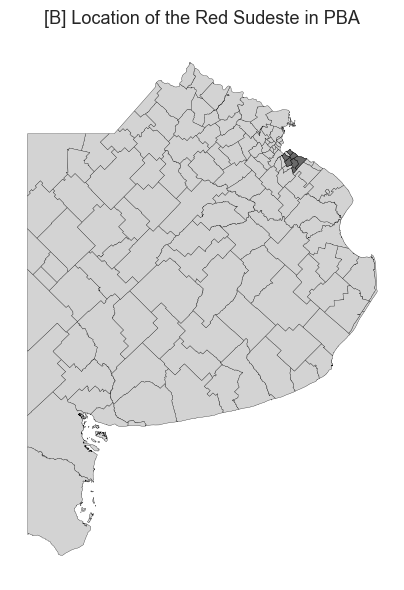

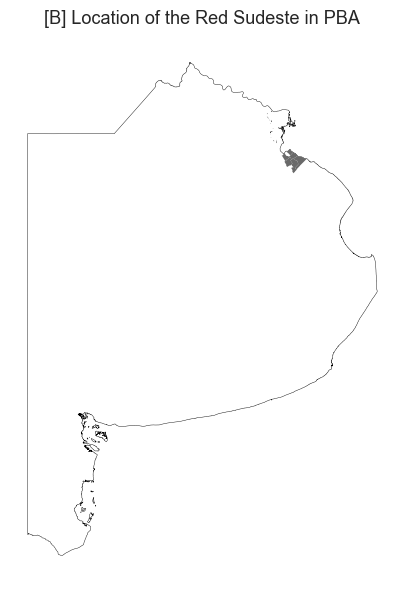

In [83]:
# -------------------------
# cargar municipios (partidos)
# -------------------------
deptos = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")

# solo partidos de la provincia de buenos aires
pba = deptos[
    deptos["in1"].astype(str).str.startswith("06")
]

# -------------------------
# partidos de la red sudeste
# -------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

# =====================================================
# OPTION 1
# todos los partidos + red sudeste resaltada
# =====================================================

fig, ax = plt.subplots(figsize=(6,6))

# todos los partidos
pba.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    linewidth=0.2
)

# partidos de la red sudeste
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(
    "[B] Location of the Red Sudeste in PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()


# =====================================================
# OPTION 2
# provincia blanca sin divisiones + red sudeste
# =====================================================

# crear geometría de toda la provincia
pba_union = pba.dissolve()

fig, ax = plt.subplots(figsize=(6,6))

# provincia completa
pba_union.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=0.3
)

# partidos de la red
sudeste.plot(
    ax=ax,
    color="dimgray",
    edgecolor="none"
)

ax.set_title(
    "[B] Location of the Red Sudeste in PBA",
    fontsize=13,
    pad=10
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# C. Los asentamientos cercanos

# RE.NA.BA.P

In [85]:

# ----------------------------
# cargar municipios (partidos)
# ----------------------------
deptos = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")
deptos = deptos.to_crs(pba.crs)  # asegurarse mismo CRS

# solo partidos de la provincia de Buenos Aires
pba = deptos[deptos["in1"].astype(str).str.startswith("06")]

# ----------------------------
# partidos de la red sudeste
# ----------------------------
red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]
# ----------------------------
# 1. Cargar archivo
# ----------------------------
# leer el archivo original
gdf = gpd.read_file("../data/renabap_geojson/20231205_info_publica.gpkg")  # o .gpkg


# ----------------------------
# 2. Filtrar solo red sudeste
# ----------------------------
# ajustar según tu columna que indique la red
red_sudeste = gdf[gdf["red"] == "sudeste"]

red_sudeste = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]

sudeste = pba[pba["nam_limpio"].isin(red_sudeste)]

KeyError: 'red'

In [ ]:

# ----------------------------
# 3. Guardar como shapefile (opcional)
# ----------------------------
# guardar como shapefile
red_sudeste.to_file("partidos_sudeste.shp")

# ----------------------------
# 4. Cargar la provincia completa
# ----------------------------
provincia = gpd.read_file("provincia_buenos_aires.shp")  # tu shapefile de la provincia

# ----------------------------
# 5. Graficar
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# provincia de fondo (blanca) con borde negro
provincia.plot(ax=ax, color="white", edgecolor="black", linewidth=1)

# partidos sudeste en gris oscuro, sin bordes internos
red_sudeste.plot(ax=ax, color="dimgray", edgecolor="dimgray", linewidth=0)

# quitar ejes y ticks
ax.set_axis_off()

plt.tight_layout()
plt.show()

Generando red general con filtro de al menos 4 traslados...
Registros luego de filtros: 496
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 11
Aristas en red: 23

Observaciones:
- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.
- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.


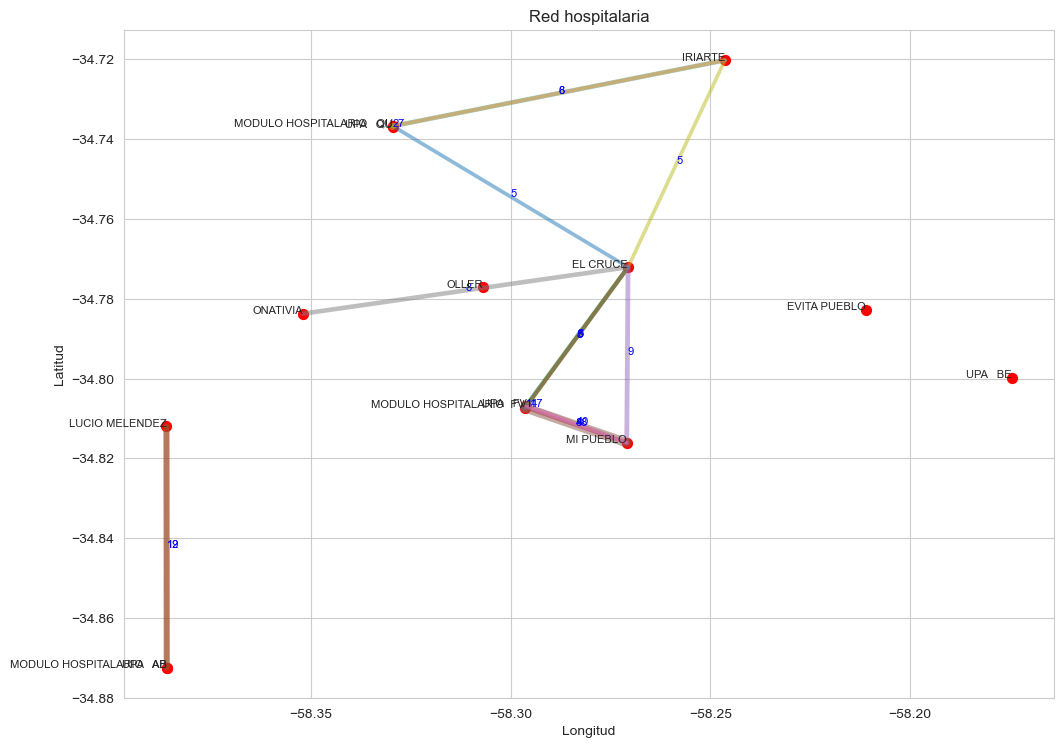

In [ ]:
# Red General (Panel D)
# Armar el grafo dirigido y pesado para todo el período
print("Generando red general con filtro de al menos 4 traslados...")
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, hosp_coords, 
    peso_minimo=4, # Filtro aplicado
    modo="estatico", 
    mostrar_resumen=True, 
    graficar=True
)

# Observaciones de la red
print("\nObservaciones:")
print("- Los enlaces restantes solo conectan hospitales del mismo distrito, con la excepción de 'El Cruce'.")
print("- 'Evita Pueblo' y 'UPA 10-BE' quedan aislados de la red principal.")

# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


In [ ]:
# Rutas (Panel E)
# Generar la red de los dos caminos más cortos desde cada hospital a través de las calles.


## Inpatients Flow throughout Time.

Se divide el período en cuatro etapas: First Wave, Intermediate, Second Wave y Post Vaccination Stage. Existe concordancia entre la evolución de los ingresos y los traslados a lo largo del período.


In [ ]:
# Gráfico de Series Temporales
# Gráfico de líneas con doble eje Y: "Admissions" (en rojo) y "Transfers" (en negro) desde abril de 2020 hasta diciembre de 2022.
# Sombras/líneas para delimitar el "National Lockdown" y las cuatro etapas mencionadas:
# 1. First Wave
# 2. Intermediate
# 3. Second Wave
# 4. Post Vaccination Stage


## Hospital Network: Evolution Throughout the Different Stages.

Se construyó una red separada para cada etapa pandémica y los nodos correspondientes a Módulos Hospitalarios y UPAs fueron separados.

**Hallazgos clave:**
- Los traslados UPA-Módulo aumentaron de la primera a la segunda ola, a pesar de que los ingresos y traslados totales fueron similares en ambas olas.
- Hubo una caída abrupta en la distancia total y mediana recorrida de la primera a la segunda ola, reflejando un aumento en la eficiencia de la red.
- En la etapa post-vacunación, se observó la esperada caída en el porcentaje de traslados sobre ingresos.


In [ ]:
# Tabla Resumen por Etapas
import numpy as np

# Estructura inicial del DataFrame para recopilar las métricas de las 4 etapas
tabla_datos = {
    'Metric': [
        'Total days', 
        'Admissions', 
        'Total transfers (%)', 
        'Ambulance transfers (%)', 
        'N of total edges | N of ambulance edges', 
        'N of transfers by edge | N of ambulance transfers by edge', 
        'Total traveled distance / Median distance'
    ],
    'First Wave': [np.nan] * 7,
    'Intermediate': [np.nan] * 7,
    'Second Wave': [np.nan] * 7,
    'Post-Vaccination Stage': [np.nan] * 7
}

df_resumen = pd.DataFrame(tabla_datos)
df_resumen.set_index('Metric', inplace=True)

# Completar con la información a medida que se procesen las etapas
display(df_resumen)


,First Wave,Intermediate,Second Wave,Post-Vaccination Stage
Metric,,,,
Total days,NaN,NaN,NaN,NaN
Admissions,NaN,NaN,NaN,NaN
Total transfers (%),NaN,NaN,NaN,NaN
Ambulance transfers (%),NaN,NaN,NaN,NaN
N of total edges | N of ambulance edges,NaN,NaN,NaN,NaN
N of transfers by edge | N of ambulance transfers by edge,NaN,NaN,NaN,NaN
Total traveled distance / Median distance,NaN,NaN,NaN,NaN


In [ ]:
# Sub-Grafos por Etapa
# Cuadrícula con 4 gráficos de red (una para cada etapa temporal)
# Tamaño de los nodos varían según la respectiva etapa para Oñativia, El Cruce, Mi Pueblo, etc.


## Inpatients Days and Topological Role / Source/Sink Role (SSR).

El rol topológico de cada hospital (Source/Sink Role) se calcula con la siguiente fórmula:

$$ssr_{i}=\frac{t_{i}^{in}-t_{i}^{out}}{t_{i}^{in}+t_{i}^{out}}$$

Donde $t_{i}^{in}$ y $t_{i}^{out}$ son los ingresos y egresos por traslados. Un valor de $ssr_{i}=1$ significa que el hospital es una fuente pura ("pure source"), mientras que $ssr_{j}=-1$ indica un sumidero puro ("pure sink").

**Clustering:** Al estudiar el SSR, surge un agrupamiento (clustering) debido a los diferentes niveles de complejidad de los hospitales.


In [ ]:
# Cálculo y Visualización del SSR
# Aplicar la fórmula del SSR a los datos.
# Generar un gráfico (scatter plot o barras) mostrando el espectro de -1 a 1 para evidenciar clústers de complejidad.


## Bibliography

1. Alvarez et al.
2. Yacobitti et al.
3. [Instituto del Cálculo (UBA-CONICET)](https://ic.fcen.uba.ar/)
4. Kohler et al.
5. Rocha et al.
